In [4]:
## Arbeitsverzeichnis festlegen, hier müssen die Daten liegen, die eingelesen werden sollen
## im Explorer Pfad kopieren und zwischen die Anführungszeichen kopieren

setwd("Blaetter.csv")

## Daten einlesen
## eingelesen wird ein csv-file (in Excel mit "Speichern unter" erstellen)
## sep = ";" (ob die Spalten mit einem Komma, einem Strichpunkt oder einem Tab getrennt werden,
## hängt von den jeweiligen Excel-Einstellungen ab)
## header = T (in der ersten Zeile stehen die Spaltenüberschriften,
## bei den Variablennamen bitte auf Groß- und Kleinschreibung achten und keine Umlaute und Sonderzeichen verwenden)

blaetter <- read.table(file="Blaetter.csv", sep =";", header = T)


### deskriptive Statistik (Uebung 1)

## über Formeln am Beispiel der Variable Blattlaenge

length(blaetter$Blattlaenge)
mean(blaetter$Blattlaenge)
sd(blaetter$Blattlaenge)
median(blaetter$Blattlaenge)
range(blaetter$Blattlaenge)
min(blaetter$Blattlaenge)
max(blaetter$Blattlaenge)
max(blaetter$Blattlaenge) - min(blaetter$Blattlaenge)
IQR(blaetter$Blattlaenge)
summary(blaetter$Blattlaenge)


## einfacher geht's über ein package

library(psych)

# für nur eine Variable
describe(blaetter$Blattlaenge)

# für alle Variablen
describe(blaetter)



### auf eine Gattung einschränken (Uebung 2)

#nur Ahorn auswaehlen
Ahorn <- subset(blaetter, Baum == "Ahorn")
describe(Ahorn)


### deskriptive Statistik für den ganzen Datensatz, aber für jede Baumgattung (Gruppierungsvariable Baum)
describeBy(blaetter, blaetter$Baum)



### Graphik (Uebung 3)

library(tidyverse)
## beinhaltet das package ggplot2, mit dem Graphiken erstellt werden können
## weiterführende links: https://www.tidyverse.org/
## https://ggplot2.tidyverse.org/
## https://r-graph-gallery.com/index.html


# den Baumarten können verschiedene Farben zugewiesen werden
cbPalette_Baum <- c("#FFFF00", "#FFB90F","#A0522D", "#008000", "#00FF00")


p_blattlaenge <- ggplot(blaetter, aes(x=Baum, y=Blattlaenge, fill = Baum)) +
  geom_boxplot() +
  scale_fill_manual(values=cbPalette_Baum) +
  theme(axis.text = element_text(size = 14), axis.title = element_text(size = 16),
        legend.text=element_text(size = 16), plot.title = element_text(size = 20)) +
  labs(x = "Baumgattung", y = "Blattlänge [mm]", title = "mittlere Blattlänge der einzelnen Baumgattungen")
p_blattlaenge




### Histogramm (Uebung 4)
## mit "binwidth" kann die Klassenbreite festgelegt werden

p_histogram <- ggplot(blaetter, aes(Blattlaenge)) +
  geom_histogram(binwidth=30, fill="#69b3a2", color="#e9ecef") +
  scale_fill_manual(values=cbPalette_Baum) +
  theme(axis.text = element_text(size = 14), axis.title = element_text(size = 16),
        legend.text=element_text(size = 16), plot.title = element_text(size = 20)) +
  labs(x = "Blattlänge", y = "Häufigkeit", title = "Häufigkeitsverteilung Blattlänge")
p_histogram


SyntaxError: invalid syntax (3067866028.py, line 20)

In [10]:
import pandas as pd

blaetter = pd.read_csv("Blaetter.csv", sep=";")

# <- DAS ist die wichtige Fix-Zeile
blaetter.columns = blaetter.columns.str.strip()

bl = blaetter["Blattlaenge"]

print(len(bl))
print(bl.mean())
print(bl.std())
print(bl.median())
print((bl.min(), bl.max()))
print(bl.max() - bl.min())
print(bl.quantile(0.75) - bl.quantile(0.25))
print(bl.describe())

# =========================
# Nur Ahorn auswählen
# =========================
Ahorn = blaetter[blaetter["Baum"] == "Ahorn"]
print(Ahorn.describe())

# =========================
# Statistik nach Baumgattung
# =========================
print(blaetter.groupby("Baum")["Blattlaenge"].describe())

# =========================
# Boxplot
# =========================

cbPalette_Baum = ["#FFFF00", "#FFB90F", "#A0522D", "#008000", "#00FF00"]

plt.figure(figsize=(8,6))
sns.boxplot(data=blaetter, x="Baum", y="Blattlaenge", palette=cbPalette_Baum)
plt.xlabel("Baumgattung")
plt.ylabel("Blattlänge [mm]")
plt.title("Mittlere Blattlänge der einzelnen Baumgattungen")
plt.show()

# =========================
# Histogramm
# =========================

plt.figure(figsize=(8,6))
plt.hist(bl, bins=30, color="#69b3a2", edgecolor="white")
plt.xlabel("Blattlänge")
plt.ylabel("Häufigkeit")
plt.title("Häufigkeitsverteilung Blattlänge")
plt.show()

KeyError: 'Blattlaenge'

Spaltennamen: ["'Datum'", "'Baum'", "'Umfang_10cm'", "'Umfang_1m'", "'Blattlaenge'", "'Gewicht'", "'Farbe'", "'Standort'", "'Frassspuren'", "'Fundort'"]
Verwende Spalte für Blattlänge: Blattlaenge
n = 381
Mittelwert = 101.65013123359579
Std-Abweichung = 46.55775565708508
Median = 95.0
Min/Max = 6.0 270.0
Spannweite = 264.0
IQR = 53.0
describe():
count    381.000000
mean     101.650131
std       46.557756
min        6.000000
25%       71.000000
50%       95.000000
75%      124.000000
max      270.000000
Name: Blattlaenge, dtype: float64

Statistik Ahorn:
count    104.000000
mean     139.144231
std       56.344023
min       13.000000
25%       96.750000
50%      134.000000
75%      177.250000
max      270.000000
Name: Blattlaenge, dtype: float64

Statistik nach Baumgattung:
       count        mean        std   min    25%    50%     75%    max
Baum                                                                  
Ahorn  104.0  139.144231  56.344023  13.0  96.75  134.0  177.25  270.0
Birk

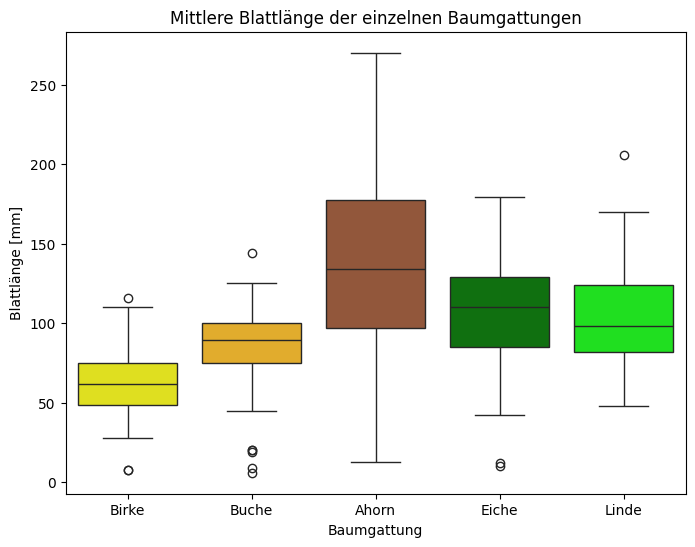

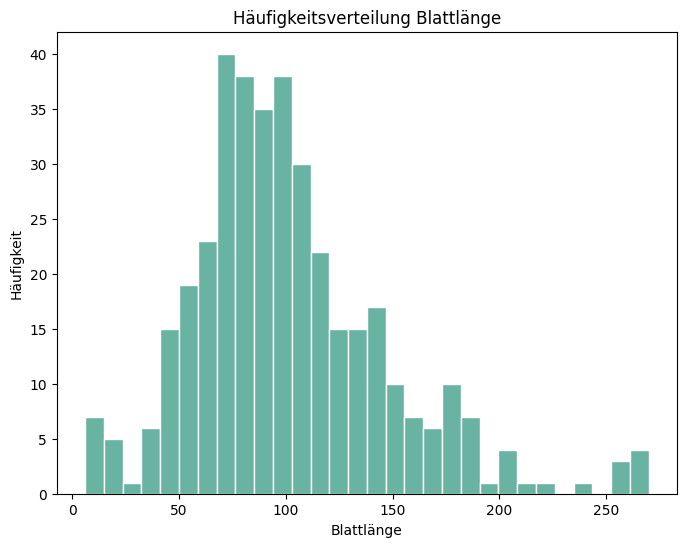

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# CSV einlesen
blaetter = pd.read_csv("Blaetter.csv", sep=",")
# oder noch einfacher:
# blaetter = pd.read_csv("Blaetter.csv")   # pandas erkennt das , meist von selbst

# Spaltennamen von Leerzeichen bereinigen
blaetter.columns = blaetter.columns.str.strip()

# 1) Zur Kontrolle: Spaltennamen anzeigen
print("Spaltennamen:", [repr(c) for c in blaetter.columns])

# 2) Automatisch die Blattlängen-Spalte finden
blatt_col = None
for c in blaetter.columns:
    if "Blatt" in c:      # alles, wo 'Blatt' im Namen vorkommt
        blatt_col = c
        break

if blatt_col is None:
    raise ValueError("Keine Spalte mit 'Blatt' im Namen gefunden!")

print(f"Verwende Spalte für Blattlänge: {blatt_col}")

bl = blaetter[blatt_col]

# =========================
# Deskriptive Statistik
# =========================

print("n =", len(bl))
print("Mittelwert =", bl.mean())
print("Std-Abweichung =", bl.std())
print("Median =", bl.median())
print("Min/Max =", bl.min(), bl.max())
print("Spannweite =", bl.max() - bl.min())
print("IQR =", bl.quantile(0.75) - bl.quantile(0.25))
print("describe():")
print(bl.describe())

# =========================
# Nur Ahorn auswählen
# =========================
Ahorn = blaetter[blaetter["Baum"] == "Ahorn"]
print("\nStatistik Ahorn:")
print(Ahorn[blatt_col].describe())

# =========================
# Statistik nach Baumgattung
# =========================
print("\nStatistik nach Baumgattung:")
print(blaetter.groupby("Baum")[blatt_col].describe())

# =========================
# Boxplot
# =========================

cbPalette_Baum = ["#FFFF00", "#FFB90F", "#A0522D", "#008000", "#00FF00"]

plt.figure(figsize=(8,6))
sns.boxplot(
    data=blaetter,
    x="Baum",
    y=blatt_col,
    hue="Baum",                 # NEU
    palette=cbPalette_Baum,
    legend=False               # sonst doppelte Legende
)
plt.xlabel("Baumgattung")
plt.ylabel("Blattlänge [mm]")
plt.title("Mittlere Blattlänge der einzelnen Baumgattungen")
plt.show()

# =========================
# Histogramm
# =========================

plt.figure(figsize=(8,6))
plt.hist(bl, bins=30, color="#69b3a2", edgecolor="white")
plt.xlabel("Blattlänge")
plt.ylabel("Häufigkeit")
plt.title("Häufigkeitsverteilung Blattlänge")
plt.show()

In [14]:
# =========================
# Relevante Variablen festlegen
# =========================

variablen = {
    "Blattlänge": blatt_col,
    "Gewicht": "Gewicht"
}

# Gewicht sicher in numerisch umwandeln
blaetter["Gewicht"] = pd.to_numeric(blaetter["Gewicht"], errors="coerce")

# =========================
# Lage- und Streuungsparameter berechnen
# =========================

for name, col in variablen.items():
    print("\n==============================")
    print(f"Lage- & Streuungsparameter für {name}")
    print("==============================")

    data = blaetter[col].dropna()  # fehlende Werte entfernen

    print("n =", len(data))                     # Stichprobenumfang
    print("Mittelwert =", data.mean())          # arithm. Mittel
    print("Median =", data.median())            # Median
    print("Minimum =", data.min())              # Minimum
    print("Maximum =", data.max())              # Maximum
    print("Spannweite =", data.max() - data.min())
    print("Standardabweichung =", data.std())   # Streuung
    print("Varianz =", data.var())              # Varianz
    print("IQR =", data.quantile(0.75) - data.quantile(0.25))  # Interquartilsabstand

    print("\ndescribe():")
    print(data.describe())


Lage- & Streuungsparameter für Blattlänge
n = 381
Mittelwert = 101.65013123359579
Median = 95.0
Minimum = 6.0
Maximum = 270.0
Spannweite = 264.0
Standardabweichung = 46.55775565708508
Varianz = 2167.6246118248378
IQR = 53.0

describe():
count    381.000000
mean     101.650131
std       46.557756
min        6.000000
25%       71.000000
50%       95.000000
75%      124.000000
max      270.000000
Name: Blattlaenge, dtype: float64

Lage- & Streuungsparameter für Gewicht
n = 280
Mittelwert = 1.4304642857142855
Median = 0.5
Minimum = 0.05
Maximum = 64.0
Spannweite = 63.95
Standardabweichung = 4.0641608883407265
Varianz = 16.517403726318484
IQR = 1.2249999999999999

describe():
count    280.000000
mean       1.430464
std        4.064161
min        0.050000
25%        0.300000
50%        0.500000
75%        1.525000
max       64.000000
Name: Gewicht, dtype: float64


In [19]:
import pandas as pd
from docx import Document

# =========================
# CSV einlesen
# =========================
blaetter = pd.read_csv("Blaetter.csv", sep=",")

# Spaltennamen bereinigen
blaetter.columns = blaetter.columns.str.strip()

# =========================
# Relevante Variablen festlegen
# =========================

# Automatisch Blattlängen-Spalte finden
blatt_col = None
for c in blaetter.columns:
    if "Blatt" in c:
        blatt_col = c
        break

if blatt_col is None:
    raise ValueError("Keine Spalte mit 'Blatt' im Namen gefunden!")

# Gewicht numerisch machen (Sicherheit)
blaetter["Gewicht"] = blaetter["Gewicht"].astype(str).str.replace(",", ".", regex=False)
blaetter["Gewicht"] = pd.to_numeric(blaetter["Gewicht"], errors="coerce")

variablen = {
    "Blattlänge": blatt_col,
    "Gewicht": "Gewicht"
}

# =========================
# Lage- & Streuungsparameter berechnen
# =========================

ergebnisse = []

for name, col in variablen.items():
    data = blaetter[col].dropna()

    params = {
        "Variable": name,
        "n": len(data),
        "Mittelwert": data.mean(),
        "Median": data.median(),
        "Minimum": data.min(),
        "Maximum": data.max(),
        "Spannweite": data.max() - data.min(),
        "Standardabweichung": data.std(),
        "Varianz": data.var(),
        "IQR": data.quantile(0.75) - data.quantile(0.25)
    }

    ergebnisse.append(params)

df_export = pd.DataFrame(ergebnisse)

# =========================
# ALS EXCEL SPEICHERN
# =========================

df_export.to_excel("Lage_und_Streuungsparameter_Bericht.xlsx", index=False)

# =========================
# ALS WORD SPEICHERN
# =========================

doc = Document()
doc.add_heading("Lage- und Streuungsparameter", level=1)

p = doc.add_paragraph()
p.add_run("Datensatz: Blattlänge und Gewicht\n").bold = True
p.add_run("Alle Werte wurden aus dem vollständigen Datensatz berechnet.\n")

table = doc.add_table(rows=1, cols=len(df_export.columns))
table.style = "Table Grid"

# Kopfzeile
hdr_cells = table.rows[0].cells
for i, col in enumerate(df_export.columns):
    hdr_cells[i].text = col

# Datenzeilen
for _, row in df_export.iterrows():
    row_cells = table.add_row().cells
    for i, val in enumerate(row):
        if isinstance(val, float):
            row_cells[i].text = f"{val:.2f}"
        else:
            row_cells[i].text = str(val)

doc.save("Lage_und_Streuungsparameter_Bericht.docx")

# =========================
# AUSGABE
# =========================

print("\nFERTIG! Dateien erstellt:")
print("- Lage_und_Streuungsparameter_Bericht.xlsx")
print("- Lage_und_Streuungsparameter_Bericht.docx")


FERTIG! Dateien erstellt:
- Lage_und_Streuungsparameter_Bericht.xlsx
- Lage_und_Streuungsparameter_Bericht.docx


In [21]:
birke = blaetter[blaetter["Baum"] == "Birke"]

In [23]:
variablen_birke = {
    "Blattlänge (Birke)": blatt_col,
    "Gewicht (Birke)": "Gewicht"
}

print("\n==============================")
print("Lage- & Streuungsparameter nur für BIRKE")
print("==============================")

for name, col in variablen_birke.items():
    data = birke[col].dropna()

    print("\n", name)
    print("------------------------------")
    print("n =", len(data))
    print("Mittelwert =", data.mean())
    print("Median =", data.median())
    print("Minimum =", data.min())
    print("Maximum =", data.max())
    print("Spannweite =", data.max() - data.min())
    print("Standardabweichung =", data.std())
    print("Varianz =", data.var())
    print("IQR =", data.quantile(0.75) - data.quantile(0.25))

    ergebnisse_birke = []

for name, col in variablen_birke.items():
    data = birke[col].dropna()
    ergebnisse_birke.append({
        "Variable": name,
        "n": len(data),
        "Mittelwert": data.mean(),
        "Median": data.median(),
        "Minimum": data.min(),
        "Maximum": data.max(),
        "Spannweite": data.max() - data.min(),
        "Standardabweichung": data.std(),
        "Varianz": data.var(),
        "IQR": data.quantile(0.75) - data.quantile(0.25)
    })

df_birke = pd.DataFrame(ergebnisse_birke)
df_birke.to_excel("Statistik_Birke.xlsx", index=False)


Lage- & Streuungsparameter nur für BIRKE

 Blattlänge (Birke)
------------------------------
n = 75
Mittelwert = 62.576
Median = 62.0
Minimum = 7.5
Maximum = 116.0
Spannweite = 108.5
Standardabweichung = 20.10642522019106
Varianz = 404.26833513513515
IQR = 26.5

 Gewicht (Birke)
------------------------------
n = 58
Mittelwert = 1.6667241379310345
Median = 0.31
Minimum = 0.05
Maximum = 64.0
Spannweite = 63.95
Standardabweichung = 8.349814450702574
Varianz = 69.71940136116153
IQR = 0.675


  Baumgattung  Mittelwert  Standardabweichung    n
0       Ahorn  139.144231           56.344023  104
1       Birke   62.576000           20.106425   75
2       Buche   86.164773           24.470921   88
3       Eiche  105.600000           35.029809   65
4       Linde  104.448980           33.212737   49


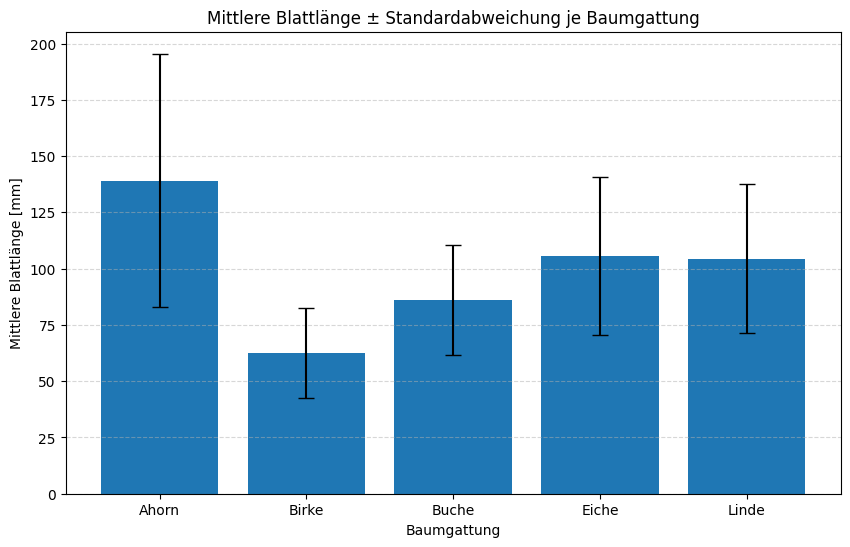

In [31]:
# =========================
# Mittelwert & Standardabweichung je Baumgattung
# =========================

stats_baum = (
    blaetter
    .groupby("Baum")[blatt_col]
    .agg(["mean", "std", "count"])
    .reset_index()
)

stats_baum.columns = ["Baumgattung", "Mittelwert", "Standardabweichung", "n"]

print(stats_baum)

# =========================
# Balkendiagramm mit Fehlerbalken
# =========================

plt.figure(figsize=(10, 6))

plt.bar(
    stats_baum["Baumgattung"],
    stats_baum["Mittelwert"],
    yerr=stats_baum["Standardabweichung"],
    capsize=6
)

plt.xlabel("Baumgattung")
plt.ylabel("Mittlere Blattlänge [mm]")
plt.title("Mittlere Blattlänge ± Standardabweichung je Baumgattung")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

stats_baum.to_excel("Statistik_MittlereBlattlaenge.xlsx", index=False)

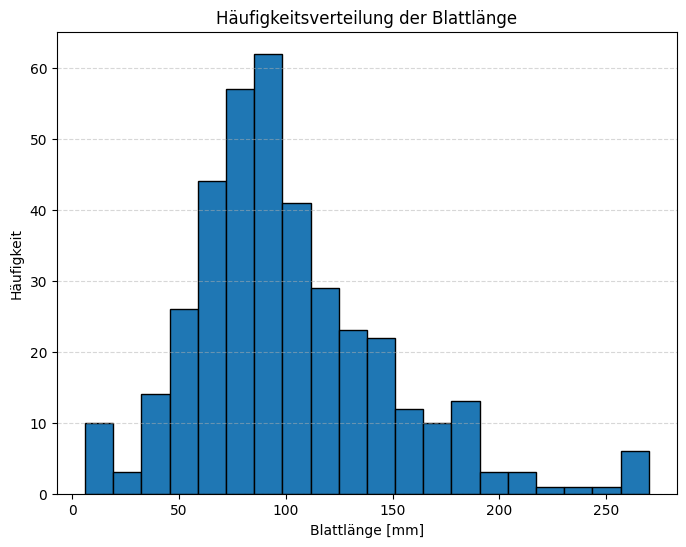

In [26]:
plt.figure(figsize=(8, 6))

plt.hist(
    blaetter[blatt_col].dropna(),  # fehlende Werte entfernen
    bins=20,                       # Klassenanzahl
    edgecolor="black"
)

plt.xlabel("Blattlänge [mm]")
plt.ylabel("Häufigkeit")
plt.title("Häufigkeitsverteilung der Blattlänge")

plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()